In [1]:
#installing hugging face's nlp package
#import all the libraries
!pip install nlp

In [2]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random
def show_history(h):
  epochs_trained = len(h.history['loss'])
  plt.figure(figsize=(16,6))

  plt.subplot(1,2,1)
  plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
  plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
  plt.ylim([0., 1.])
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
  plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()

print('using tensorlow version', tf.__version__)

using tensorlow version 2.19.0


In [3]:
!rm -rf /root/.cache/huggingface
!rm -rf /root/.cache/datasets


In [4]:
!pip install -U datasets


In [5]:
from datasets import load_dataset

dataset = load_dataset("emotion")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
train = dataset['train']
val = dataset['validation']
test = dataset['test']

In [8]:
def get_tweet(data):
  tweets = [x['text'] for x in data]
  labels = [x['label']for x in data]
  return tweets, labels

In [9]:
tweets , labels = get_tweet(train)

In [10]:
tweets[0], labels[0]

('i didnt feel humiliated', 0)

In [11]:
dataset["train"].features["label"]


ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

In [12]:
tweets[1], labels[1]

('i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 0)

In [13]:
#Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer


In [14]:
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(tweets)
tokenizer.texts_to_sequences([tweets[0]])

[[2, 139, 3, 679]]

In [15]:
tweets[0]

'i didnt feel humiliated'

In [16]:
import matplotlib.pyplot as plt


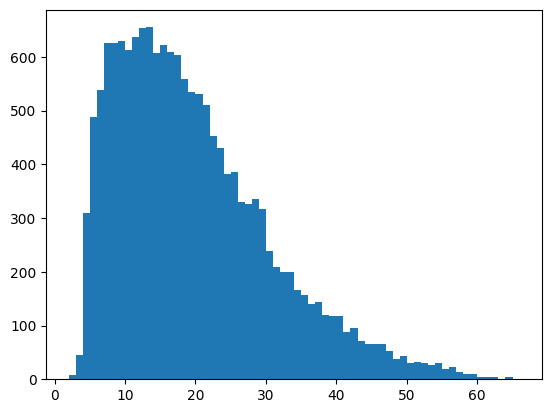

In [17]:
#padding and truncated sequences
lengths = [len(t.split(' ')) for t in tweets]
plt.hist(lengths, bins = len(set(lengths)))
plt.show()

In [18]:
maxlen = 50
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
def get_sequences(tokenizer,tweets):
  sequences = tokenizer.texts_to_sequences(tweets)
  padded = pad_sequences(sequences, truncating='post', padding='post', maxlen=maxlen)
  return padded

In [20]:
padded_train_seq = get_sequences(tokenizer,tweets)

In [21]:
padded_train_seq[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

In [22]:
#preparing the labels
classes = set(labels)
print(classes)

{0, 1, 2, 3, 4, 5}


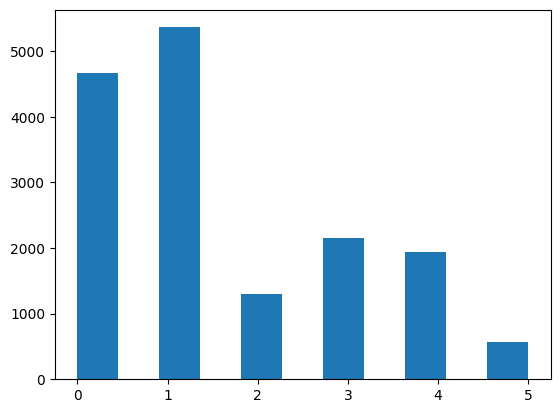

In [23]:
plt.hist(labels, bins=11)
plt.show()

In [24]:
class_to_index = dict((c,i) for i,c in enumerate(classes))
index_to_class = dict((v,k) for v,k in class_to_index.items())

In [25]:
class_to_index

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [26]:
index_to_class

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [27]:
names_to_ids = lambda labels: np.array([class_to_index.get(x) for x in labels])

In [28]:
dataset["train"].features["label"].names  #optional


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [29]:
import numpy as np
train_labels = names_to_ids(labels)
print(train_labels[0])

0


In [30]:
#creating the model
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_length=maxlen),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(20, return_sequences=True)
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(20)
    ),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
#training the model
val_tweets, val_labels = get_tweet(val)
val_seq = get_sequences(tokenizer, val_tweets)
val_labels = names_to_ids(val_labels)

In [33]:
val_tweets[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon',
 np.int64(0))

In [34]:
h = model.fit(
    padded_train_seq, train_labels,
    validation_data = (val_seq, val_labels),
    epochs = 20,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.3435 - loss: 1.5795 - val_accuracy: 0.6775 - val_loss: 0.9099
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.7353 - loss: 0.6995 - val_accuracy: 0.8040 - val_loss: 0.5231
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.8890 - loss: 0.3344 - val_accuracy: 0.8725 - val_loss: 0.4230
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9316 - loss: 0.2137 - val_accuracy: 0.8855 - val_loss: 0.3633
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9540 - loss: 0.1452 - val_accuracy: 0.8855 - val_loss: 0.3796
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9671 - loss: 0.1027 - val_accuracy: 0.8865 - val_loss: 0.4012
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9730 - loss: 0.0820 - val_accuracy: 0.8910 - val_loss: 0.3854
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9766 - loss: 0.0727 - 

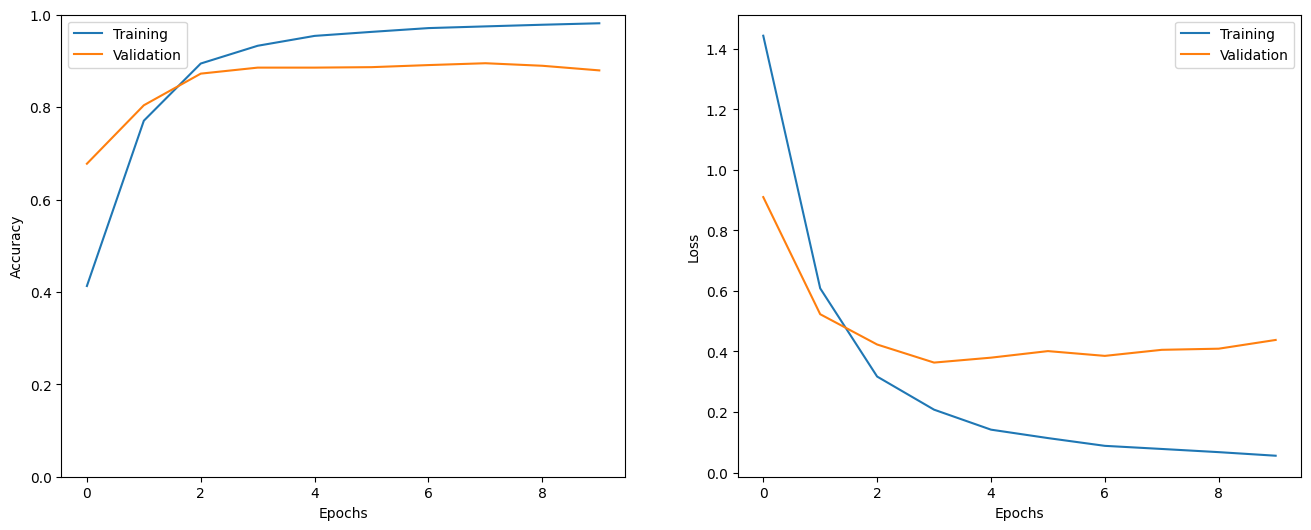

In [35]:
#evaluating the model
show_history(h)

In [36]:
test_tweets, test_labels = get_tweet(test)
test_seq = get_sequences(tokenizer, test_tweets)
test_labels = names_to_ids(test_labels)

In [37]:
_ = model.evaluate(test_seq, test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8771 - loss: 0.4441


In [38]:
import random
import numpy as np

# label index → class name
index_to_class = dataset["train"].features["label"].names

# pick random test example
i = random.randint(0, len(test_labels) - 1)

print('Sentence:', test_tweets[i])
print('Actual Emotion:', index_to_class[test_labels[i]])

# prediction
p = model.predict(np.expand_dims(test_seq[i], axis=0))[0]
pred_class = index_to_class[np.argmax(p)]

print('Predicted Emotion:', pred_class)


Sentence: im really not taking in information lately it could explain why ive been feeling sort of discontent lately
Actual Emotion: sadness
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
Predicted Emotion: sadness


In [39]:
import numpy as np

preds = model.predict(test_seq)
pred_labels = np.argmax(preds, axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def show_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(classes)), classes, rotation=45)
    plt.yticks(range(len(classes)), classes)
    plt.colorbar()
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()


In [41]:
class_names = dataset["train"].features["label"].names


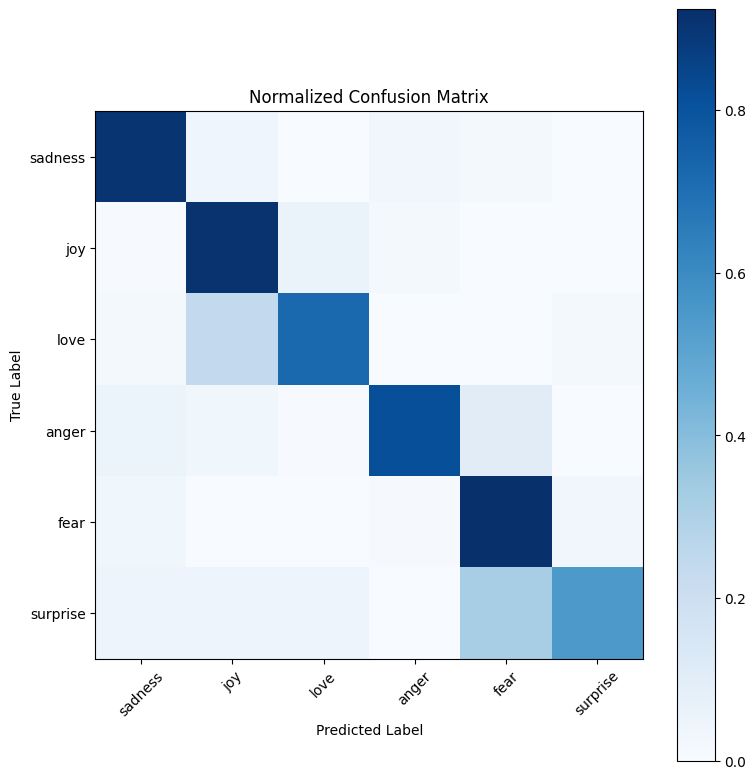

In [42]:
show_confusion_matrix(test_labels, pred_labels, class_names)
